In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from itertools import product

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    RandomForestClassifier, 
    ExtraTreesClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier
)

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

In [3]:
# Cargar datos
df = pd.read_csv("../Base.csv")

In [5]:
# Dimensiones
print(f"Shape: {df.shape}")

Shape: (1000000, 32)


In [6]:
# Tipos de datos
print(df.dtypes)

fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards                 

In [7]:
# Valores faltantes
print(df.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [8]:
# Primeras filas
print(df.head())

   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89            20            0.010095   
2                            14            40            0.012316   
3                            14            30            0.006991   
4                            29            40            5.742626   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0              102.453711           AA          1059  ..

In [9]:
# Función para numerizar variables categóricas
def one_hot(df, columna):
    return pd.get_dummies(df, columns=[columna], drop_first=True, dtype=int)

In [10]:
# Categorizar variables de tipo object
df = one_hot(df, 'payment_type')
df = one_hot(df, 'employment_status') 
df = one_hot(df, 'housing_status')
df = one_hot(df, 'source')
df = one_hot(df, 'device_os')

In [11]:
# Resumen rápido de nuevo df
print(df.info())
df.to_csv("base-limpia.csv", index=False)
df = pd.read_csv("base-limpia.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 48 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   zip_count_4w                      1000000 non-null  int64  
 9   velocity_6h                       1000000 non-null  float64
 10  velocity_24h                      1000000 non-null  float64
 11  velocity_4w                       1000

In [12]:
# Separar target de features
target = 'fraud_bool'
X = df.drop(columns=[target])
y = df[target]

In [13]:
# Separar conjunto de entrenamiento y prueba 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 800000 muestras
Test:  200000 muestras


In [14]:
def detectar_outliers(df, columnas):
    """Versión simple - Solo muestra número de outliers"""
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5*IQR
        lim_sup = Q3 + 1.5*IQR
        outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")
        

In [15]:
# Solo variables continuas (las que realmente tienen sentido para outliers)
columnas_continuas = [
    'income',
    'name_email_similarity',
    'prev_address_months_count',
    'current_address_months_count',
    'customer_age',
    'days_since_request',
    'intended_balcon_amount',
    'zip_count_4w',
    'velocity_6h',
    'velocity_24h',
    'velocity_4w',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w',
    'credit_risk_score',
    'bank_months_count',
    'proposed_credit_limit',
    'session_length_in_minutes',
    'device_distinct_emails_8w',
    'device_fraud_count'
]

detectar_outliers(df, columnas_continuas)

income: 0 outliers (0.0%)
name_email_similarity: 0 outliers (0.0%)
prev_address_months_count: 157320 outliers (15.7%)
current_address_months_count: 41001 outliers (4.1%)
customer_age: 1373 outliers (0.1%)
days_since_request: 94834 outliers (9.5%)
intended_balcon_amount: 222702 outliers (22.3%)
zip_count_4w: 59871 outliers (6.0%)
velocity_6h: 9005 outliers (0.9%)
velocity_24h: 2917 outliers (0.3%)
velocity_4w: 0 outliers (0.0%)
bank_branch_count_8w: 175243 outliers (17.5%)
date_of_birth_distinct_emails_4w: 9734 outliers (1.0%)
credit_risk_score: 8729 outliers (0.9%)
bank_months_count: 0 outliers (0.0%)
proposed_credit_limit: 241742 outliers (24.2%)
session_length_in_minutes: 78789 outliers (7.9%)
device_distinct_emails_8w: 31933 outliers (3.2%)
device_fraud_count: 0 outliers (0.0%)


In [16]:
def visualizar_distribuciones(df, features):        
    # Calcular dinámicamente el número de filas necesario
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols  # Redondear hacia arriba
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    
    # Asegurar que axes sea 2D incluso con 1 fila
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Crear lista de colores automática
    colors = plt.cm.tab20.colors  # Usar paleta con 20 colores
    
    for idx, feature in enumerate(features):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        # Histograma con KDE
        sns.histplot(data=df, x=feature, kde=True, bins=20, ax=ax, color=colors[idx % len(colors)])
        ax.set_title(f'Distribución de {feature}')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
    
    # Ocultar subplots no utilizados
    for idx in range(len(features), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()

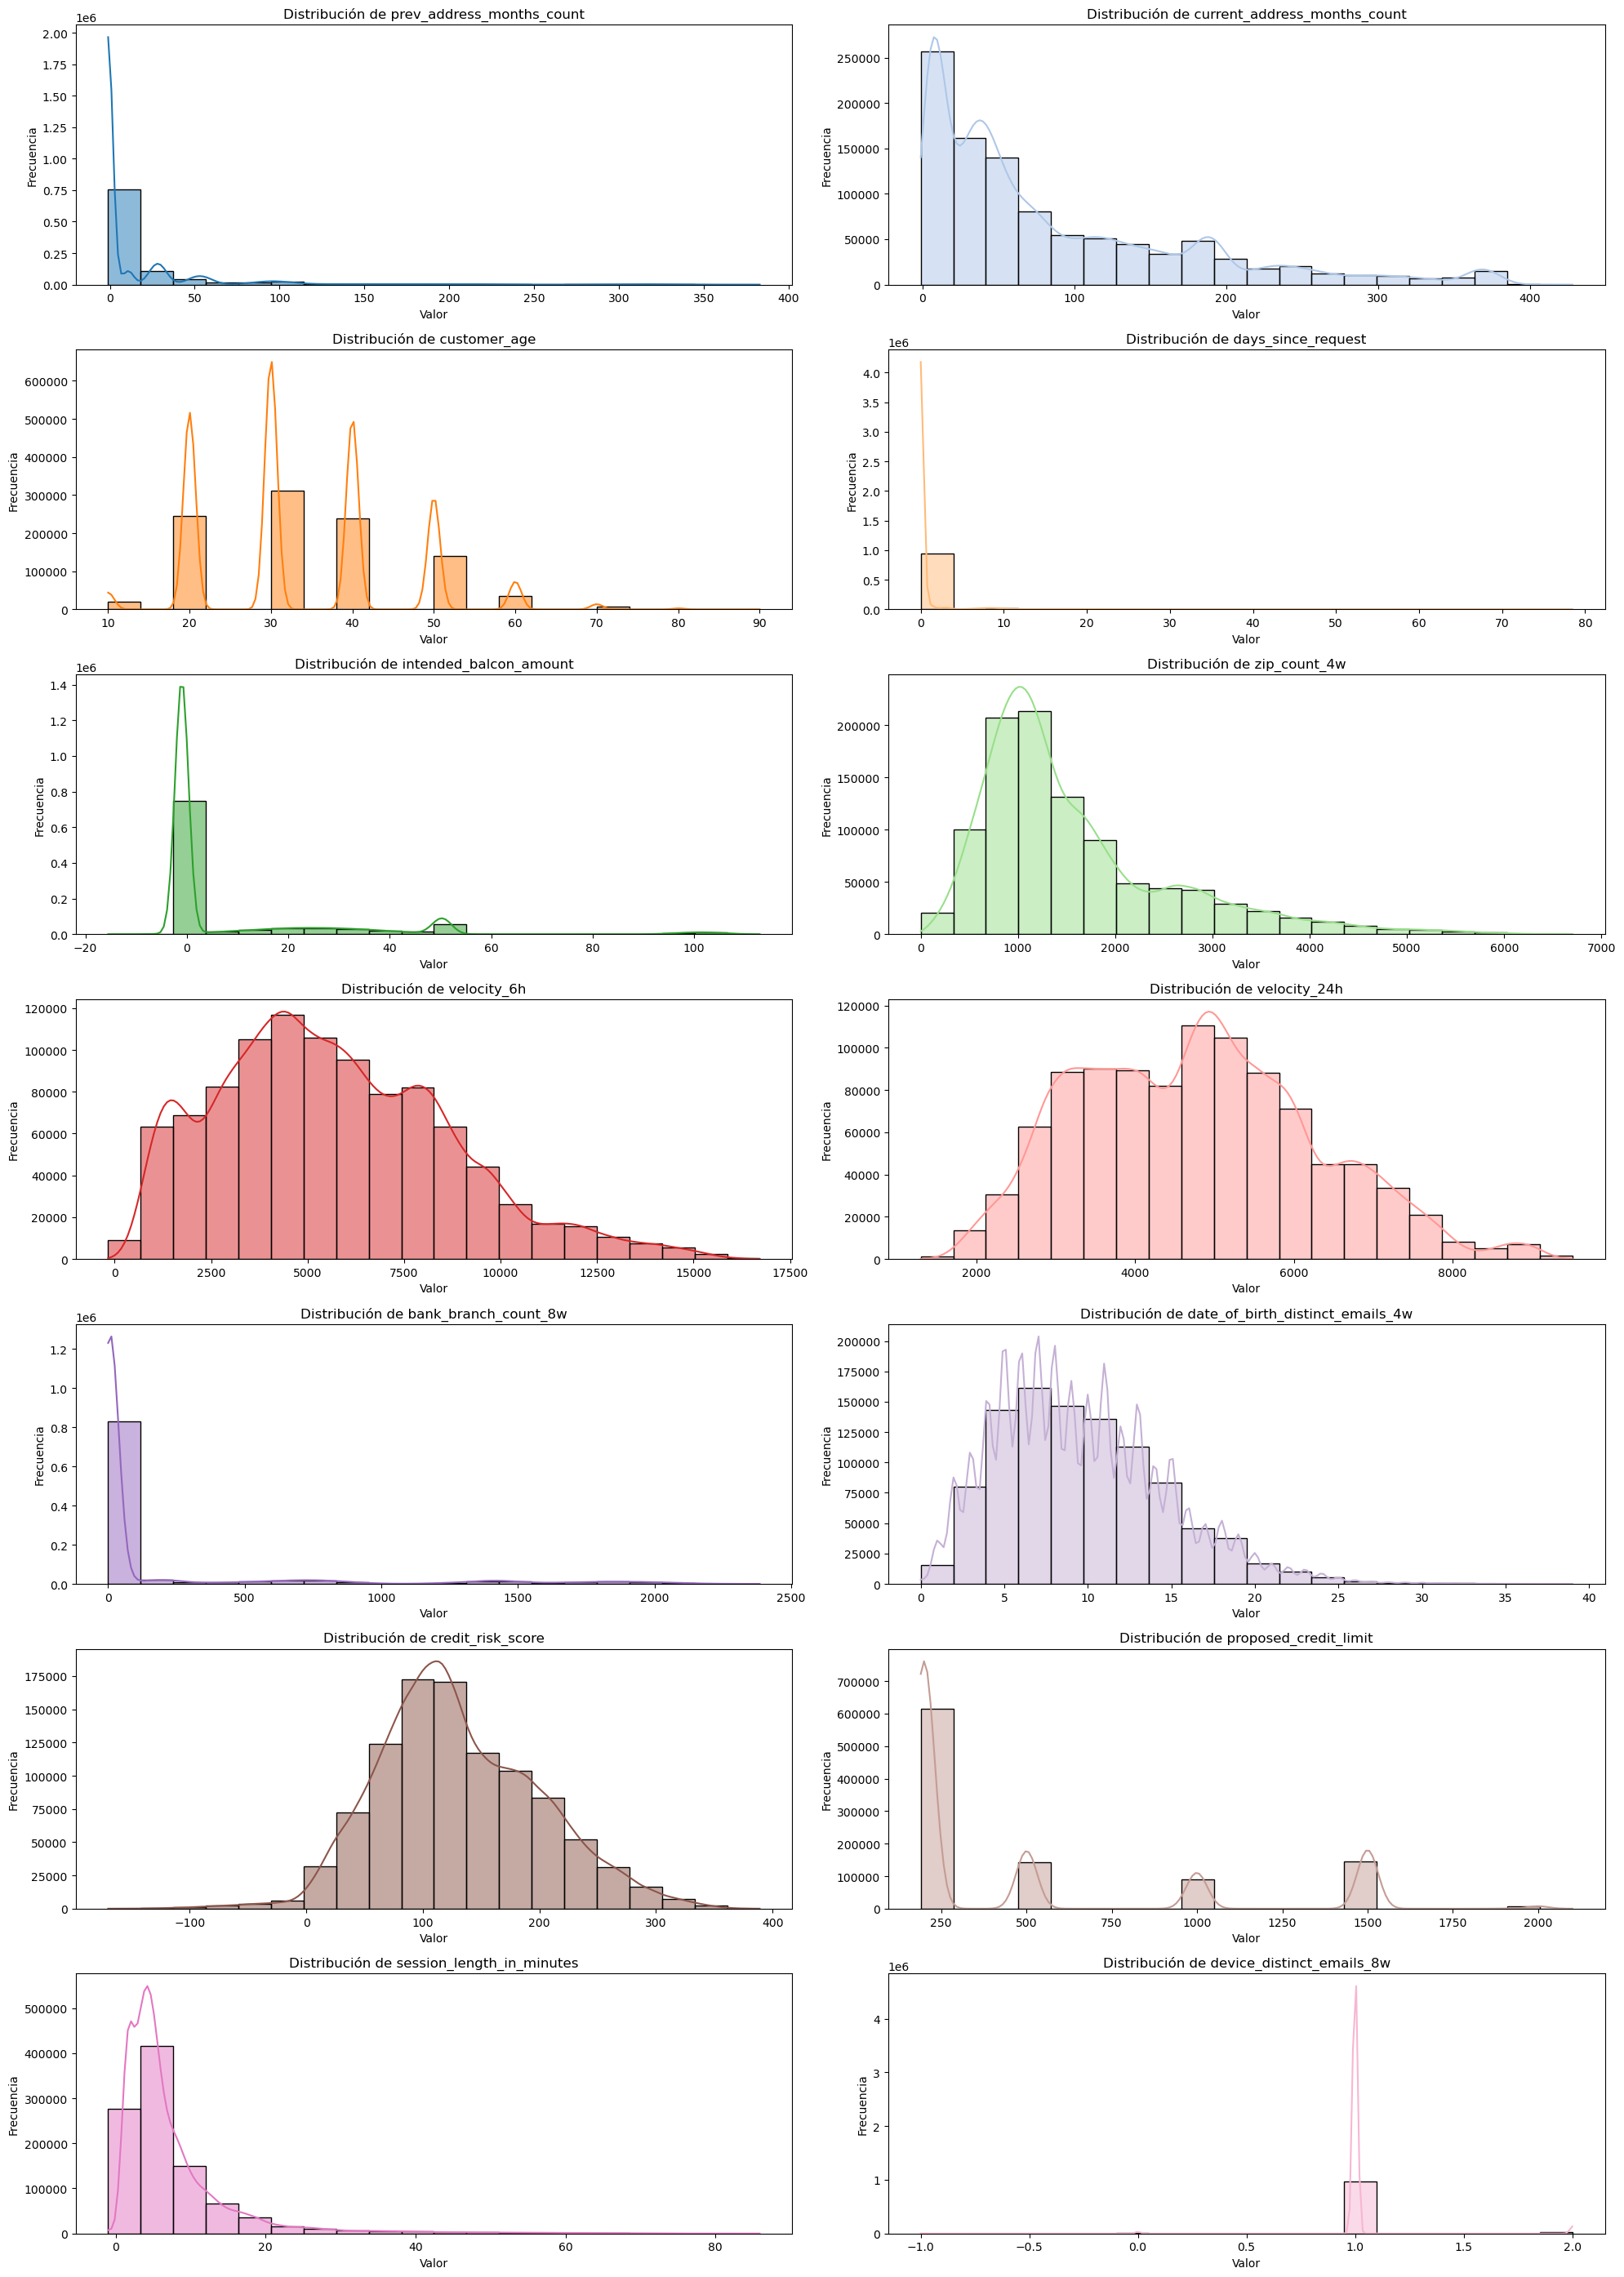

In [17]:
# Columnas que tienen outliers (porcentaje > 0)
columnas_con_outliers = [
    'prev_address_months_count',
    'current_address_months_count',
    'customer_age',
    'days_since_request',
    'intended_balcon_amount',
    'zip_count_4w',
    'velocity_6h',
    'velocity_24h',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w',
    'credit_risk_score',
    'proposed_credit_limit',
    'session_length_in_minutes',
    'device_distinct_emails_8w'
]

visualizar_distribuciones(df, columnas_con_outliers)

In [18]:
def matriz_correlacion(df,features):  
    # Matriz de correlación
    corr_matrix = df[features].corr()
    #print(corr_matrix)

    # Visualización
    fig, ax = plt.subplots(figsize=(40, 28))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, ax=ax, cbar_kws={'label': 'Correlación'})
    ax.set_title('Matriz de Correlación - Iris Features')
    plt.tight_layout()
    #plt.savefig('.correlacion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

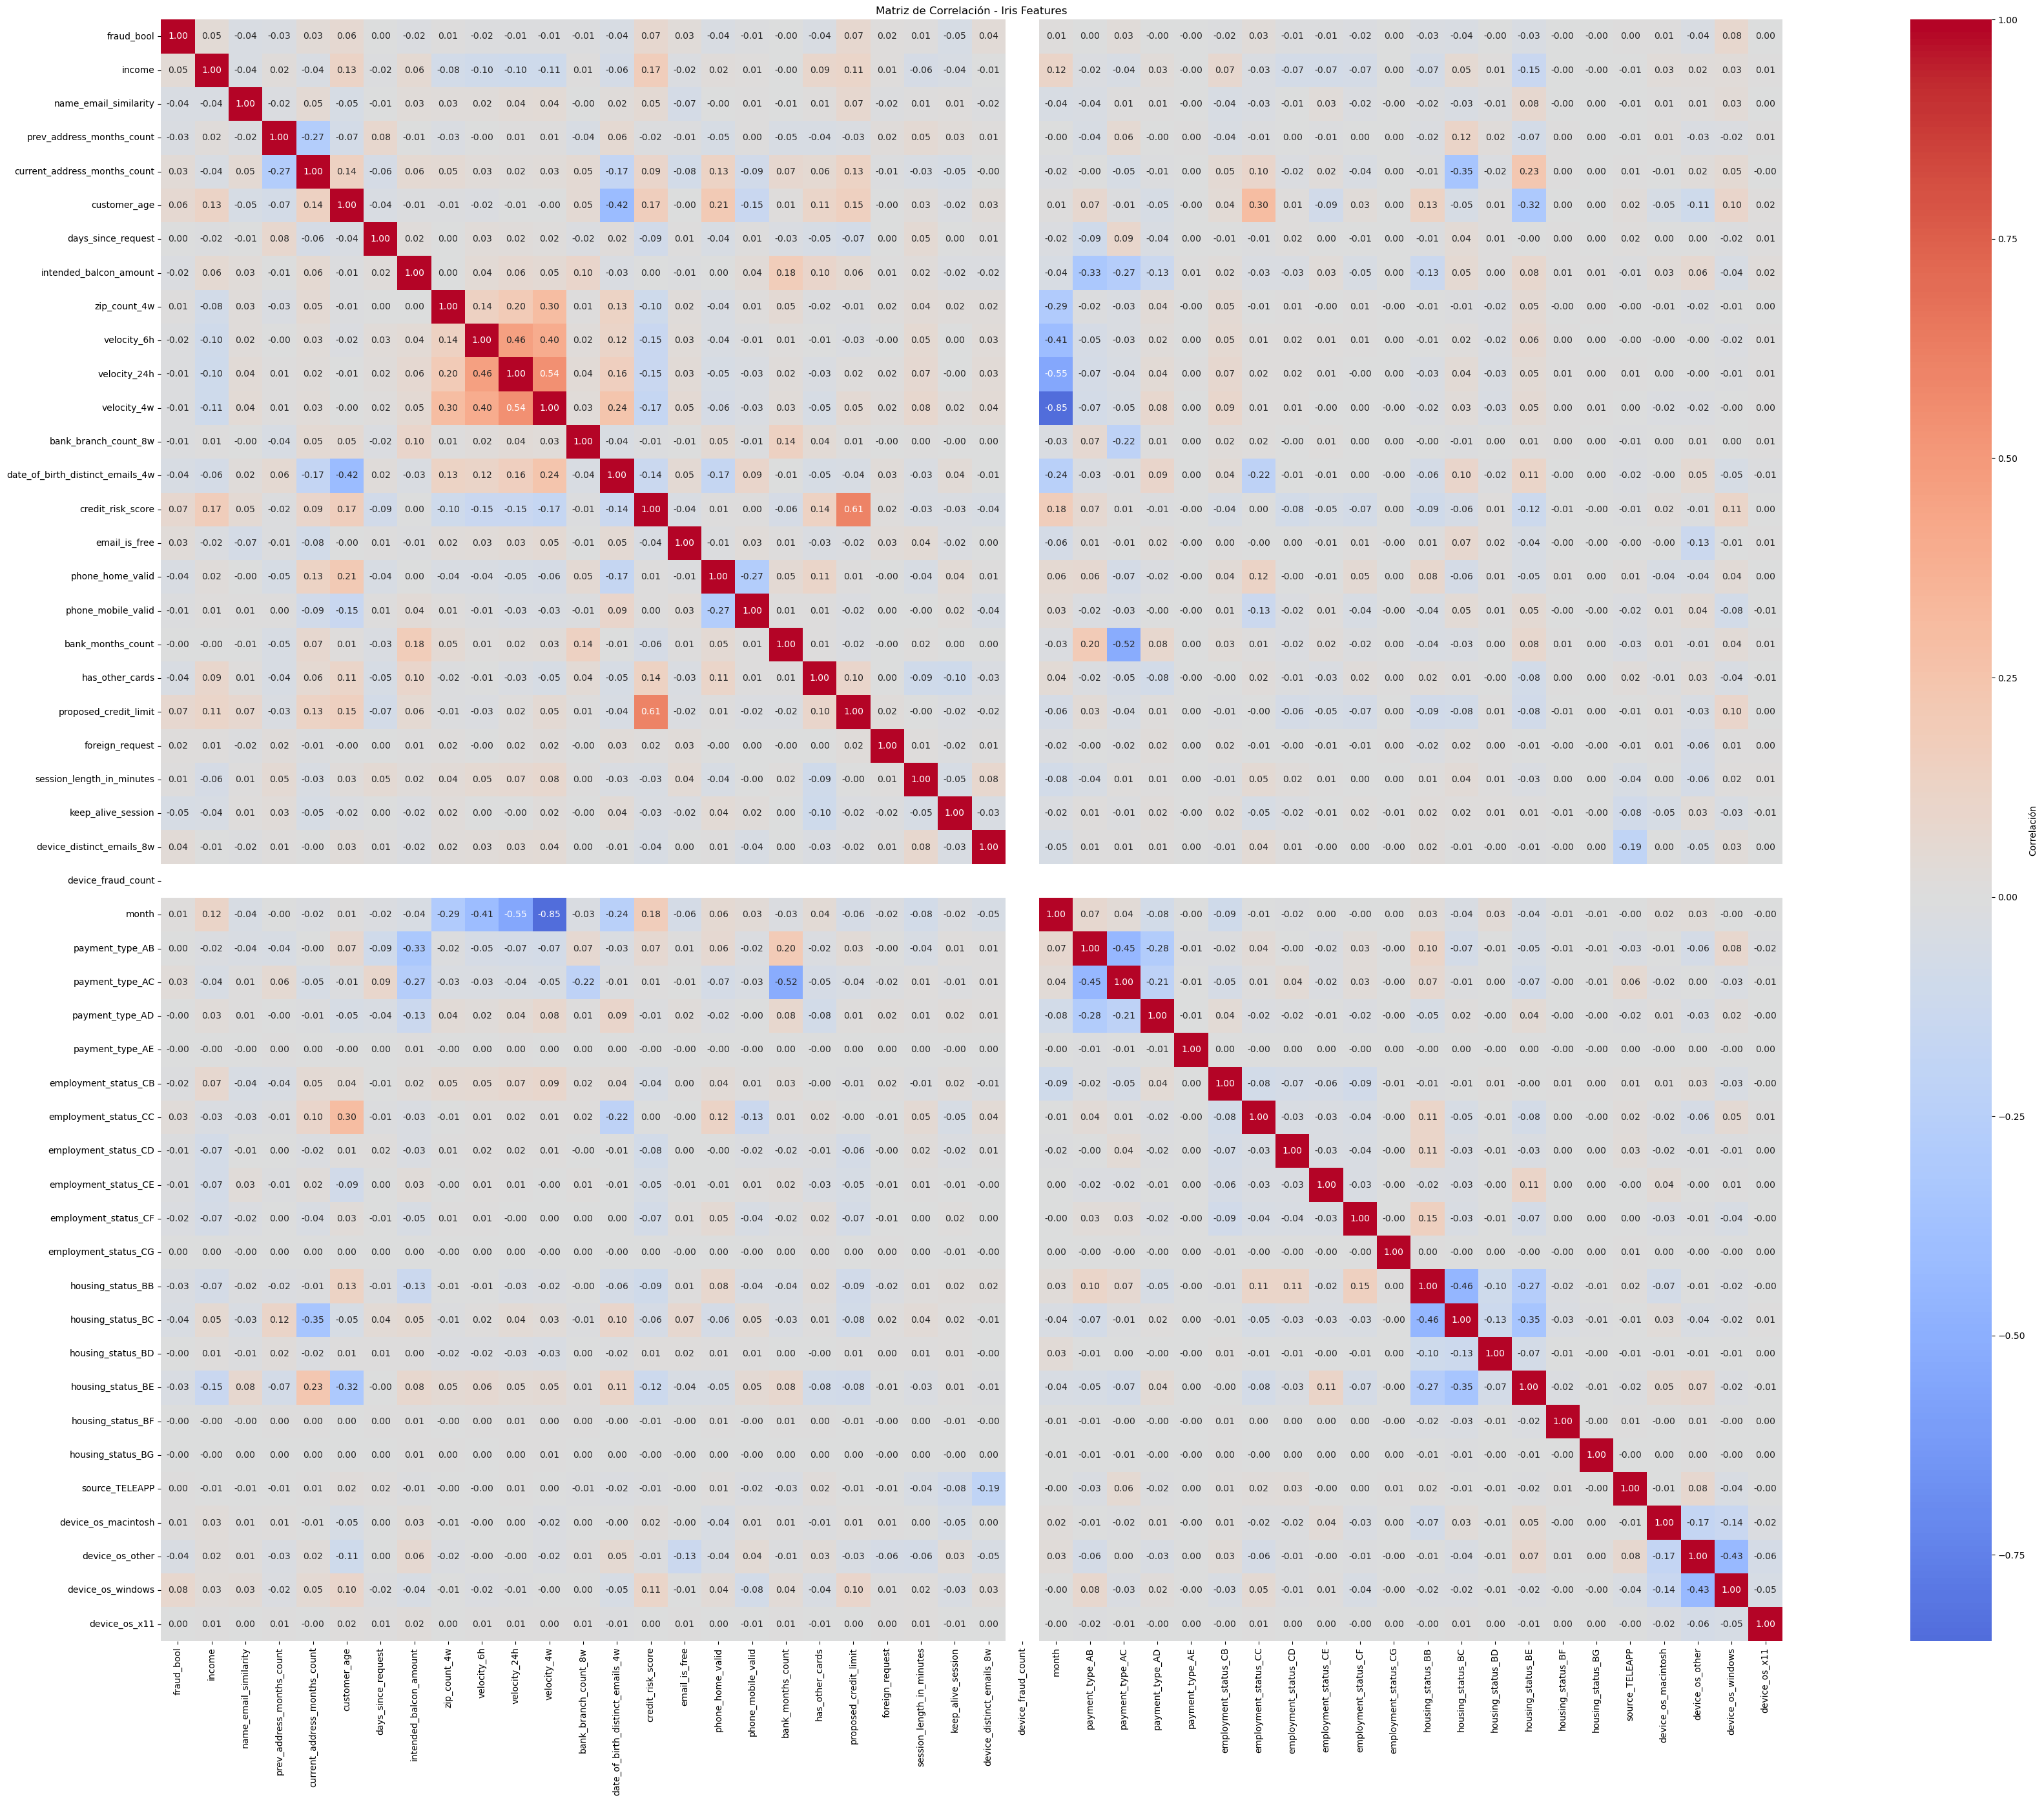

In [19]:
# Lista completa de todas las columnas
todas_columnas = [
    'fraud_bool',
    'income',
    'name_email_similarity',
    'prev_address_months_count',
    'current_address_months_count',
    'customer_age',
    'days_since_request',
    'intended_balcon_amount',
    'zip_count_4w',
    'velocity_6h',
    'velocity_24h',
    'velocity_4w',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w',
    'credit_risk_score',
    'email_is_free',
    'phone_home_valid',
    'phone_mobile_valid',
    'bank_months_count',
    'has_other_cards',
    'proposed_credit_limit',
    'foreign_request',
    'session_length_in_minutes',
    'keep_alive_session',
    'device_distinct_emails_8w',
    'device_fraud_count',
    'month',
    'payment_type_AB',
    'payment_type_AC',
    'payment_type_AD',
    'payment_type_AE',
    'employment_status_CB',
    'employment_status_CC',
    'employment_status_CD',
    'employment_status_CE',
    'employment_status_CF',
    'employment_status_CG',
    'housing_status_BB',
    'housing_status_BC',
    'housing_status_BD',
    'housing_status_BE',
    'housing_status_BF',
    'housing_status_BG',
    'source_TELEAPP',
    'device_os_macintosh',
    'device_os_other',
    'device_os_windows',
    'device_os_x11'
]

matriz_correlacion(df,todas_columnas)

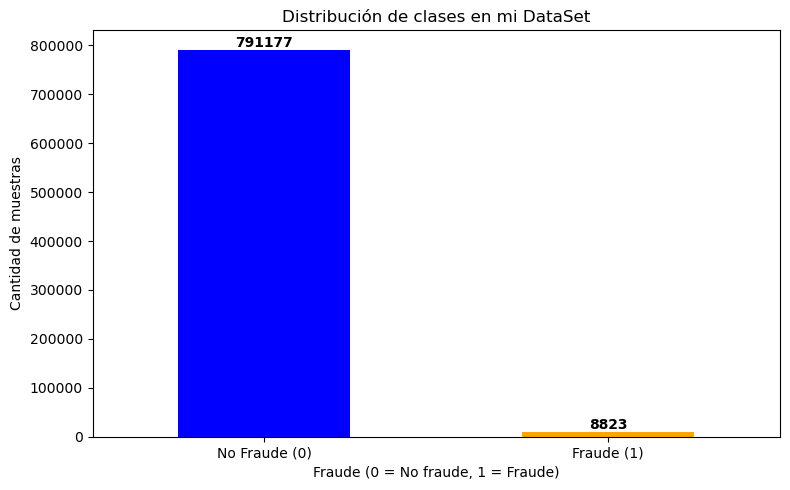

In [20]:
def imbalance_representatividad(y_series):   
    
    # Visualización
    fig, ax = plt.subplots(figsize=(8, 5))
    y_series.value_counts().plot(kind='bar', ax=ax, color=['blue', 'orange'])
    ax.set_title('Distribución de clases en mi DataSet')
    ax.set_xlabel('Fraude (0 = No fraude, 1 = Fraude)')
    ax.set_ylabel('Cantidad de muestras')
    ax.set_xticklabels(['No Fraude (0)', 'Fraude (1)'], rotation=0)
    
    # Añadir valores en las barras
    for i, v in enumerate(y_series.value_counts().values):
        ax.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    plt.close()

# Llamar a la función correctamente
imbalance_representatividad(y_train)

## Tratamiento de outliers

En este problema no se eliminan observaciones extremas, ya que en detección de fraude los valores atípicos pueden contener información relevante para identificar comportamientos anómalos. Además, la clase fraudulenta está fuertemente desbalanceada, por lo que eliminar filas podría reducir todavía más la información disponible sobre la clase minoritaria.

Se aplica un tratamiento en tres pasos:

1. Los valores `-1` en variables temporales se interpretan como valores desconocidos y se imputan usando la mediana calculada únicamente en el conjunto de entrenamiento.
2. Para las variables continuas con colas largas se aplica capping mediante el criterio IQR, sustituyendo los valores extremos por el límite inferior o superior correspondiente.
3. Se añaden variables binarias indicando si un valor fue imputado o capado, para conservar información sobre la anomalía original.

Todos los parámetros del tratamiento se calculan exclusivamente sobre `X_train` y después se aplican a `X_test`, evitando data leakage.

In [21]:
from sklearn.preprocessing import RobustScaler

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

# Columnas donde el valor -1 representa ausencia/desconocido,
# no un valor extremo real.
sentinel_minus1_cols: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
]

sentinel_minus1_cols = [
    col for col in sentinel_minus1_cols 
    if col in X_train.columns
]

# Columnas continuas sobre las que sí tiene sentido aplicar capping.
# No incluimos variables binarias, one-hot, ni variables discretas de negocio.
cap_cols: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "velocity_24h",
    "bank_branch_count_8w",
    "date_of_birth_distinct_emails_4w",
    "credit_risk_score",
    "session_length_in_minutes",
]

cap_cols = [
    col for col in cap_cols 
    if col in X_train.columns
]

# Columnas detectadas como "raras" por IQR pero que NO conviene capar directamente.
# customer_age: edades discretizadas y válidas.
# proposed_credit_limit: límites de crédito por tramos comerciales.
# device_distinct_emails_8w / device_fraud_count: variables discretas de baja cardinalidad.
cols_no_capadas: list[str] = [
    "customer_age",
    "proposed_credit_limit",
    "device_distinct_emails_8w",
    "device_fraud_count",
]

print("Columnas con -1 tratadas como desconocido:")
print(sentinel_minus1_cols)

print("\nColumnas con capping IQR:")
print(cap_cols)

print("\nColumnas con outliers detectados pero no capadas:")
print(cols_no_capadas)

Columnas con -1 tratadas como desconocido:
['prev_address_months_count', 'current_address_months_count', 'bank_months_count']

Columnas con capping IQR:
['prev_address_months_count', 'current_address_months_count', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes']

Columnas con outliers detectados pero no capadas:
['customer_age', 'proposed_credit_limit', 'device_distinct_emails_8w', 'device_fraud_count']


In [22]:
def fit_sentinel_replacements(
    X: pd.DataFrame,
    columns: list[str],
    sentinel_value: int | float = -1
) -> dict[str, float]:
    """
    Calcula la mediana de entrenamiento para reemplazar valores centinela.
    Solo se usan valores distintos del centinela.
    """
    replacements: dict[str, float] = {}

    for col in columns:
        valid_values = X.loc[X[col] != sentinel_value, col]

        if valid_values.empty:
            replacements[col] = float(X[col].median())
        else:
            replacements[col] = float(valid_values.median())

    return replacements


def apply_sentinel_replacements(
    X: pd.DataFrame,
    replacements: dict[str, float],
    sentinel_value: int | float = -1,
    add_flags: bool = True
) -> pd.DataFrame:
    """
    Reemplaza valores centinela por la mediana aprendida en train.
    Opcionalmente añade una flag indicando si el valor era desconocido.
    """
    X_out = X.copy()

    for col, replacement in replacements.items():
        if col not in X_out.columns:
            continue

        missing_mask = X_out[col] == sentinel_value

        if add_flags:
            X_out[f"{col}_was_missing"] = missing_mask.astype(int)

        X_out[col] = X_out[col].astype(float)
        X_out.loc[missing_mask, col] = replacement

    return X_out


def fit_iqr_bounds(
    X: pd.DataFrame,
    columns: list[str],
    iqr_factor: float = 3.0,
    lower_fallback_quantile: float = 0.005,
    upper_fallback_quantile: float = 0.995
) -> pd.DataFrame:
    """
    Calcula límites de capping usando IQR sobre el conjunto de entrenamiento.

    Se usa iqr_factor=3.0 en lugar de 1.5 para ser conservadores:
    detectamos outliers con 1.5, pero solo capamos extremos severos.
    """
    records: list[dict[str, float | str]] = []

    for col in columns:
        q1 = float(X[col].quantile(0.25))
        q3 = float(X[col].quantile(0.75))
        iqr = q3 - q1

        if np.isclose(iqr, 0.0):
            lower_bound = float(X[col].quantile(lower_fallback_quantile))
            upper_bound = float(X[col].quantile(upper_fallback_quantile))
        else:
            lower_bound = q1 - iqr_factor * iqr
            upper_bound = q3 + iqr_factor * iqr

        records.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": float(iqr),
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        })

    return pd.DataFrame(records)


def apply_iqr_capping(
    X: pd.DataFrame,
    bounds_df: pd.DataFrame,
    add_flags: bool = True
) -> pd.DataFrame:
    """
    Aplica capping a partir de límites ya calculados en entrenamiento.
    Opcionalmente añade una flag indicando si el valor fue capado.
    """
    X_out = X.copy()

    for _, row in bounds_df.iterrows():
        col = str(row["feature"])

        if col not in X_out.columns:
            continue

        lower_bound = float(row["lower_bound"])
        upper_bound = float(row["upper_bound"])

        outlier_mask = (X_out[col] < lower_bound) | (X_out[col] > upper_bound)

        if add_flags:
            X_out[f"{col}_was_capped"] = outlier_mask.astype(int)

        X_out[col] = X_out[col].clip(lower=lower_bound, upper=upper_bound)

    return X_out

In [23]:
# 1. Aprender reemplazos de valores -1 SOLO en train
sentinel_replacements: dict[str, float] = fit_sentinel_replacements(
    X=X_train,
    columns=sentinel_minus1_cols,
    sentinel_value=-1
)

# 2. Aplicar reemplazos a train y test
X_train_sentinel = apply_sentinel_replacements(
    X=X_train,
    replacements=sentinel_replacements,
    sentinel_value=-1,
    add_flags=True
)

X_test_sentinel = apply_sentinel_replacements(
    X=X_test,
    replacements=sentinel_replacements,
    sentinel_value=-1,
    add_flags=True
)

# 3. Aprender límites IQR SOLO en train ya corregido
bounds_df = fit_iqr_bounds(
    X=X_train_sentinel,
    columns=cap_cols,
    iqr_factor=3.0
)

# 4. Aplicar capping a train y test
X_train_out = apply_iqr_capping(
    X=X_train_sentinel,
    bounds_df=bounds_df,
    add_flags=True
)

X_test_out = apply_iqr_capping(
    X=X_test_sentinel,
    bounds_df=bounds_df,
    add_flags=True
)

print("Shape original train:", X_train.shape)
print("Shape tratado train: ", X_train_out.shape)
print("Shape original test: ", X_test.shape)
print("Shape tratado test:  ", X_test_out.shape)

print("\nReemplazos usados para valores -1:")
display(pd.DataFrame.from_dict(
    sentinel_replacements,
    orient="index",
    columns=["replacement_median_train"]
))

print("\nLímites aprendidos para capping:")
display(bounds_df.round(3))

Shape original train: (800000, 47)
Shape tratado train:  (800000, 61)
Shape original test:  (200000, 47)
Shape tratado test:   (200000, 61)

Reemplazos usados para valores -1:


,replacement_median_train
prev_address_months_count,34.0
current_address_months_count,53.0
bank_months_count,15.0



Límites aprendidos para capping:


,feature,q1,q3,iqr,lower_bound,upper_bound
0,prev_address_months_count,34.000,34.000,0.000,9.000,306.000
1,current_address_months_count,20.000,130.000,110.000,-310.000,460.000
2,days_since_request,0.007,0.026,0.019,-0.050,0.084
3,intended_balcon_amount,-1.181,5.075,6.256,-19.949,23.843
4,zip_count_4w,894.000,1944.000,1050.000,-2256.000,5094.000
5,velocity_6h,3434.760,7680.991,4246.231,-9303.933,20419.683
6,velocity_24h,3593.074,5753.116,2160.042,-2887.051,12233.240
7,bank_branch_count_8w,1.000,25.000,24.000,-71.000,97.000
8,date_of_birth_distinct_emails_4w,6.000,13.000,7.000,-15.000,34.000
9,credit_risk_score,83.000,178.000,95.000,-202.000,463.000


In [24]:
def build_treatment_summary(
    X_train_treated: pd.DataFrame,
    X_test_treated: pd.DataFrame,
    sentinel_cols: list[str],
    capped_cols: list[str]
) -> pd.DataFrame:
    """
    Resume cuántos valores han sido imputados o capados en train y test.
    """
    rows: list[dict[str, int | float | str]] = []

    for col in sentinel_cols:
        flag_col = f"{col}_was_missing"

        if flag_col in X_train_treated.columns:
            train_count = int(X_train_treated[flag_col].sum())
            test_count = int(X_test_treated[flag_col].sum())

            rows.append({
                "feature": col,
                "tratamiento": "reemplazo_-1",
                "train_count": train_count,
                "train_%": train_count / len(X_train_treated) * 100,
                "test_count": test_count,
                "test_%": test_count / len(X_test_treated) * 100,
            })

    for col in capped_cols:
        flag_col = f"{col}_was_capped"

        if flag_col in X_train_treated.columns:
            train_count = int(X_train_treated[flag_col].sum())
            test_count = int(X_test_treated[flag_col].sum())

            rows.append({
                "feature": col,
                "tratamiento": "capping_IQR",
                "train_count": train_count,
                "train_%": train_count / len(X_train_treated) * 100,
                "test_count": test_count,
                "test_%": test_count / len(X_test_treated) * 100,
            })

    return pd.DataFrame(rows).sort_values(
        by=["tratamiento", "train_%"],
        ascending=[True, False]
    )


treatment_summary = build_treatment_summary(
    X_train_treated=X_train_out,
    X_test_treated=X_test_out,
    sentinel_cols=sentinel_minus1_cols,
    capped_cols=cap_cols
)

display(treatment_summary.round(3))

,feature,tratamiento,train_count,train_%,test_count,test_%
6,intended_balcon_amount,capping_IQR,139445,17.431,34753,17.376
10,bank_branch_count_8w,capping_IQR,138196,17.274,34514,17.257
5,days_since_request,capping_IQR,74986,9.373,18709,9.354
13,session_length_in_minutes,capping_IQR,27866,3.483,6898,3.449
7,zip_count_4w,capping_IQR,6593,0.824,1656,0.828
3,prev_address_months_count,capping_IQR,5913,0.739,1496,0.748
11,date_of_birth_distinct_emails_4w,capping_IQR,80,0.010,17,0.008
4,current_address_months_count,capping_IQR,0,0.000,0,0.000
8,velocity_6h,capping_IQR,0,0.000,0,0.000
9,velocity_24h,capping_IQR,0,0.000,0,0.000


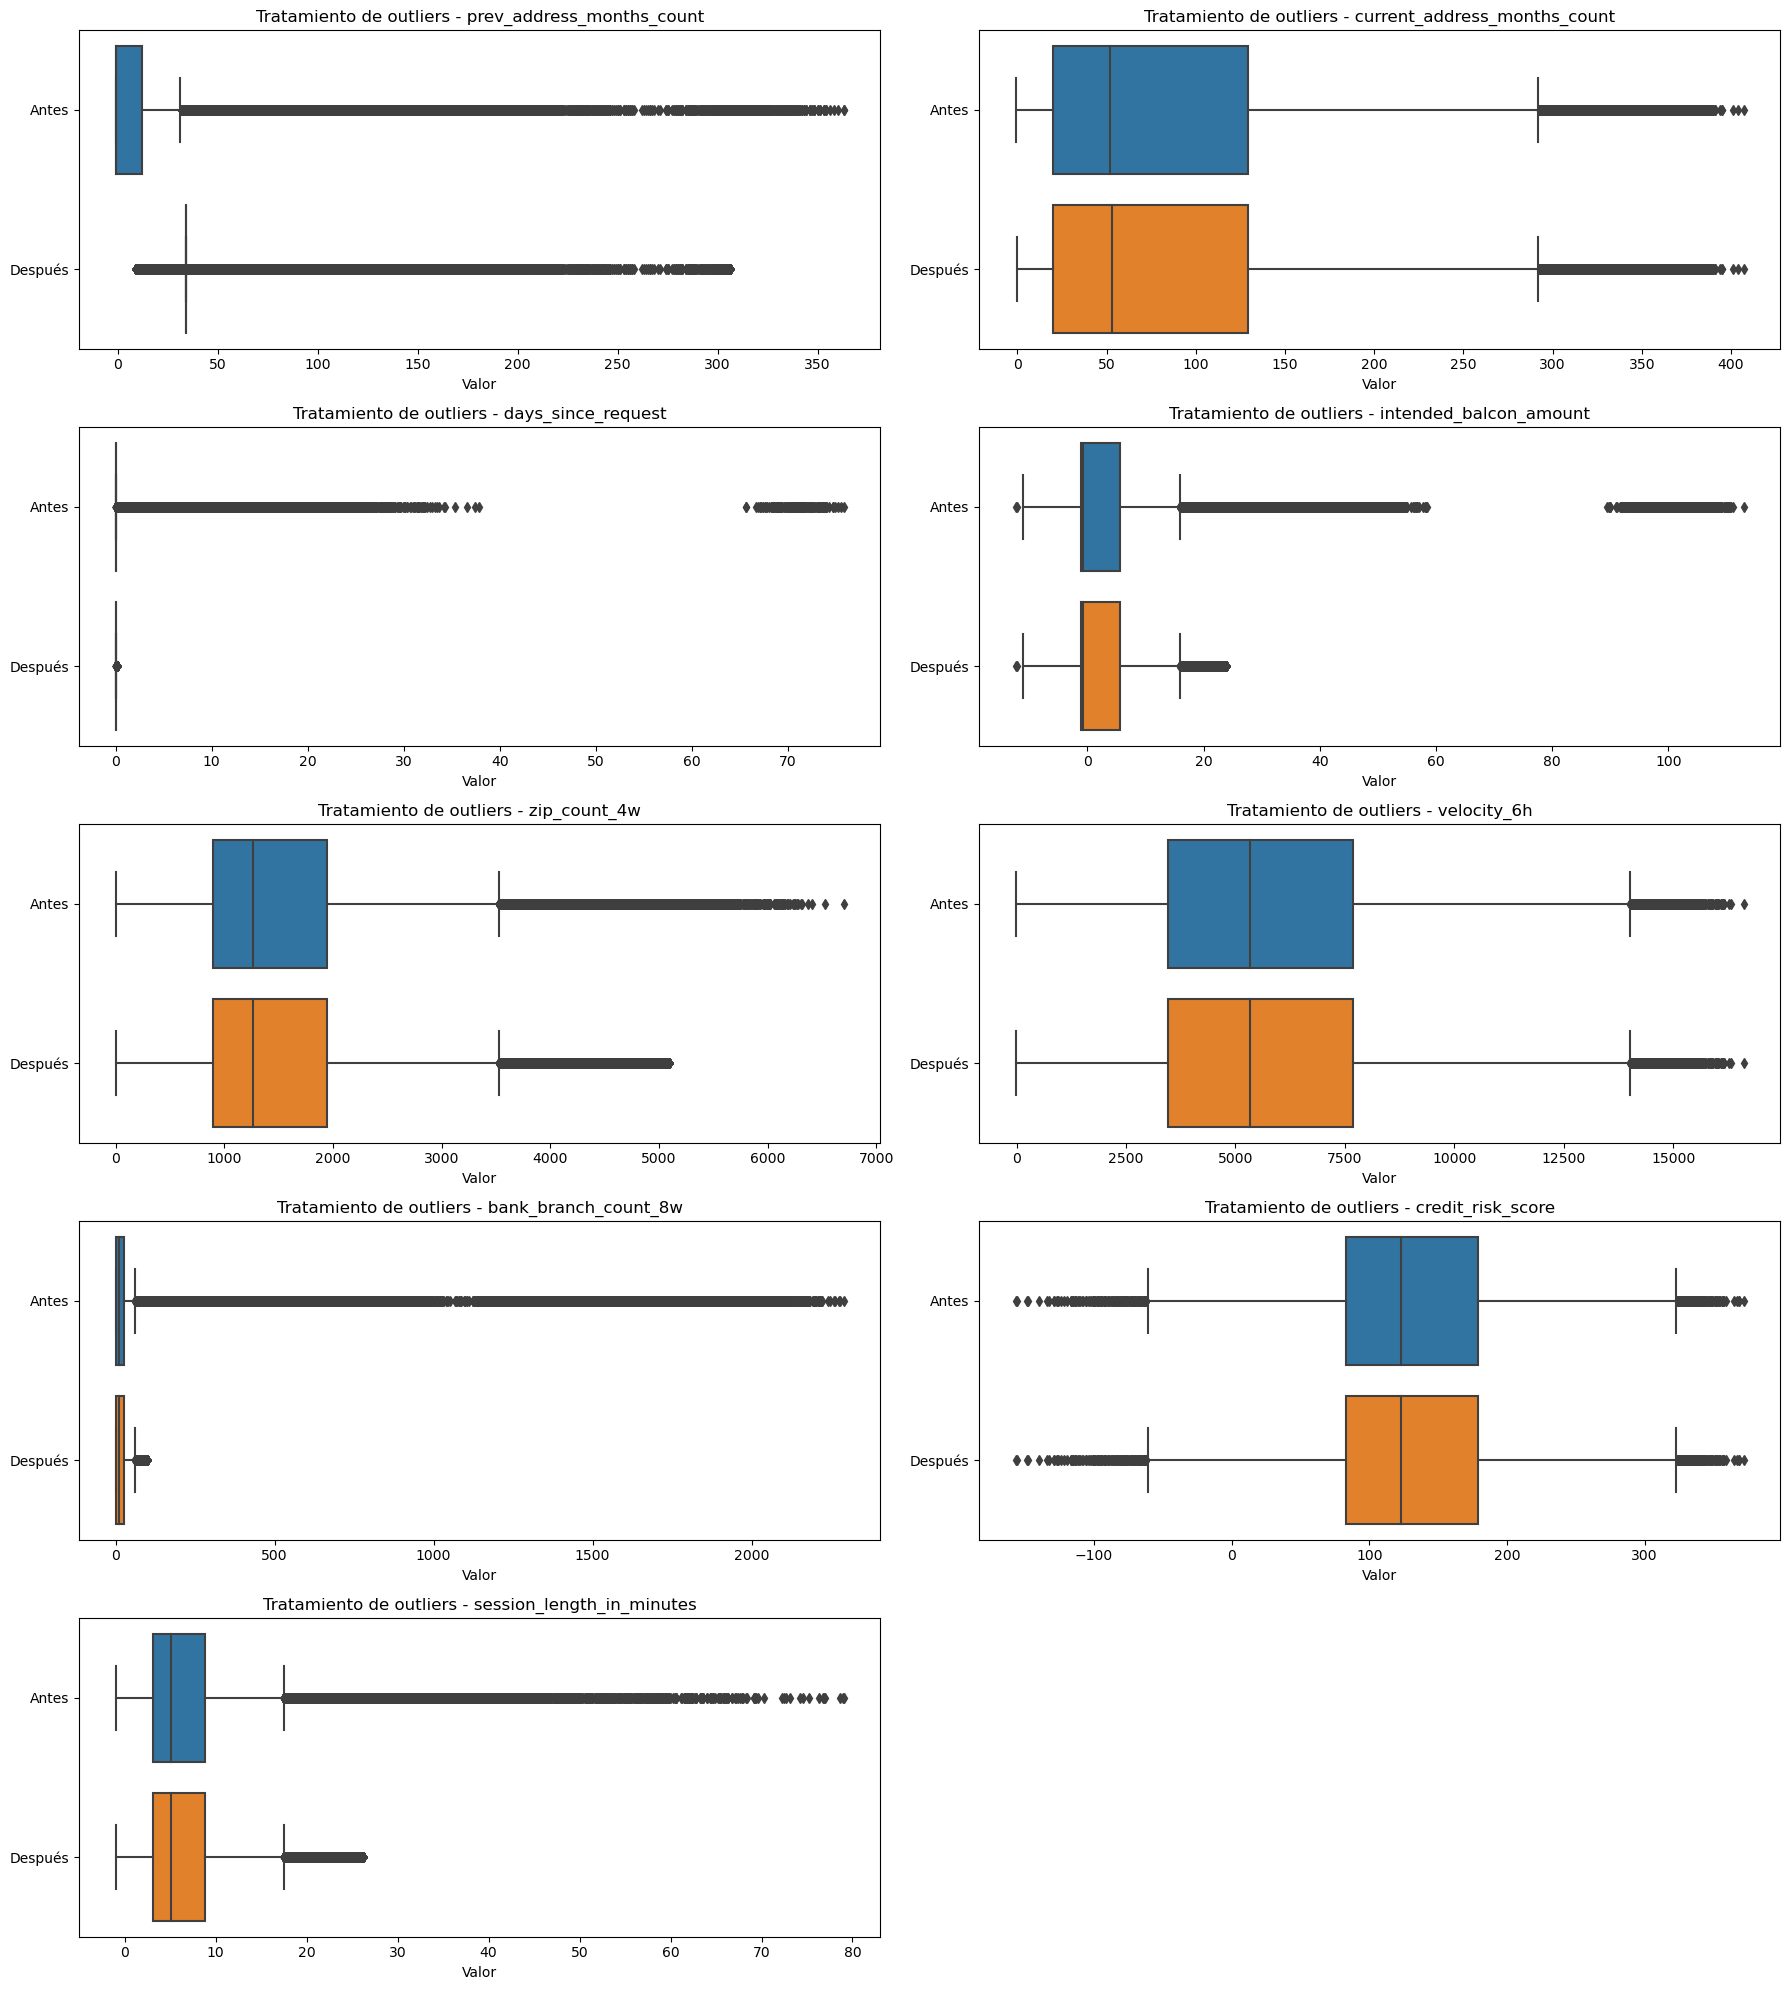

In [25]:
def visualizar_capping_antes_despues(
    X_before: pd.DataFrame,
    X_after: pd.DataFrame,
    columns: list[str],
    sample_size: int = 50_000,
    random_state: int = 42
) -> None:
    """
    Visualiza el efecto del tratamiento mediante boxplots antes/después.
    Se usa una muestra para evitar que el gráfico sea pesado.
    """
    available_cols = [
        col for col in columns
        if col in X_before.columns and col in X_after.columns
    ]

    if len(available_cols) == 0:
        print("No hay columnas disponibles para visualizar.")
        return

    sample_size = min(sample_size, len(X_before))
    sample_index = X_before.sample(
        n=sample_size,
        random_state=random_state
    ).index

    n_cols = 2
    n_rows = int(np.ceil(len(available_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 4 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(available_cols):
        plot_df = pd.DataFrame({
            "Antes": X_before.loc[sample_index, col],
            "Después": X_after.loc[sample_index, col],
        }).melt(
            var_name="Estado",
            value_name="Valor"
        )

        sns.boxplot(
            data=plot_df,
            x="Valor",
            y="Estado",
            ax=axes[idx]
        )

        axes[idx].set_title(f"Tratamiento de outliers - {col}")
        axes[idx].set_xlabel("Valor")
        axes[idx].set_ylabel("")

    for idx in range(len(available_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()


cols_visualizar_tratamiento: list[str] = [
    "prev_address_months_count",
    "current_address_months_count",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "bank_branch_count_8w",
    "credit_risk_score",
    "session_length_in_minutes",
]

visualizar_capping_antes_despues(
    X_before=X_train,
    X_after=X_train_out,
    columns=cols_visualizar_tratamiento,
    sample_size=50_000,
    random_state=RANDOM_STATE
)

In [26]:
# Detectamos columnas binarias para NO escalarlas.
binary_cols: list[str] = []

for col in X_train_out.columns:
    unique_values = set(X_train_out[col].dropna().unique())

    if unique_values.issubset({0, 1, 0.0, 1.0}):
        binary_cols.append(col)

continuous_cols_for_scaling: list[str] = [
    col for col in X_train_out.columns
    if col not in binary_cols
]

robust_scaler = RobustScaler()

X_train_scaled = X_train_out.copy()
X_test_scaled = X_test_out.copy()

X_train_scaled[continuous_cols_for_scaling] = robust_scaler.fit_transform(
    X_train_out[continuous_cols_for_scaling]
)

X_test_scaled[continuous_cols_for_scaling] = robust_scaler.transform(
    X_test_out[continuous_cols_for_scaling]
)

print("Columnas escaladas:", len(continuous_cols_for_scaling))
print("Columnas binarias no escaladas:", len(binary_cols))

display(X_train_scaled[continuous_cols_for_scaling].describe().T.head(15))

Columnas escaladas: 19
Columnas binarias no escaladas: 42


,count,mean,std,min,25%,50%,75%,max
income,800000.0,-0.074280,0.580686,-1.000000,-0.600000,0.000000e+00,0.400000,0.600000
name_email_similarity,800000.0,0.002798,0.545192,-0.928419,-0.503496,5.234240e-17,0.496504,0.957409
prev_address_months_count,800000.0,7.572515,35.400603,-25.000000,0.000000,0.000000e+00,0.000000,272.000000
current_address_months_count,800000.0,0.307664,0.802124,-0.481818,-0.300000,0.000000e+00,0.700000,3.409091
customer_age,800000.0,0.185004,0.601413,-1.000000,-0.500000,0.000000e+00,0.500000,3.000000
days_since_request,800000.0,0.350234,1.175665,-0.792616,-0.417259,-4.533352e-17,0.582741,3.582741
intended_balcon_amount,800000.0,0.872774,1.598884,-2.349869,-0.056153,8.873305e-18,0.943847,3.943847
zip_count_4w,800000.0,0.291837,0.945165,-1.201905,-0.351429,0.000000e+00,0.648571,3.648571
velocity_6h,800000.0,0.081889,0.708788,-1.292183,-0.443109,0.000000e+00,0.556891,2.684560
velocity_24h,800000.0,0.008996,0.684942,-1.588173,-0.535975,2.105272e-16,0.464025,2.201853


Para el tratamiento de outliers se evitó eliminar observaciones, ya que en detección de fraude los valores extremos pueden representar patrones anómalos relevantes. En primer lugar, los valores `-1` presentes en variables temporales se interpretaron como valores desconocidos y se sustituyeron por la mediana calculada exclusivamente sobre el conjunto de entrenamiento, añadiendo una variable indicadora para conservar dicha información. Posteriormente, se aplicó capping basado en el rango intercuartílico sobre variables continuas con colas largas. Los límites se aprendieron únicamente en el conjunto de entrenamiento y se aplicaron después al conjunto de test, evitando fuga de información. Además, se añadieron variables binarias indicando si cada valor había sido capado, permitiendo al modelo aprovechar la señal asociada a valores extremos sin que estos dominen numéricamente el aprendizaje.

In [ ]:
# SVM - RBF
# GridSearch
start_total = time.time()

pipe_rbf = Pipeline([('scaler', StandardScaler()), 
                    ('svm', SVC(kernel='rbf',
                    random_state=42, class_weight='balanced'))])

param_grid = {'svm__C': [0.1, 1, 10, 100], 
              'svm__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']}

grid_rbf = GridSearchCV(pipe_rbf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_rbf.fit(X_train, y_train)

time_total = time.time() - start_total

print(f"Mejores parámetros: {grid_rbf.best_params_}")

# Reportamos el mejor modelo
best_C = grid_rbf.best_params_['svm__C']
best_gamma = grid_rbf.best_params_['svm__gamma']
best_cv = grid_rbf.best_score_
best_test = grid_rbf.best_estimator_.score(X_test, y_test)
best_sv = grid_rbf.best_estimator_.named_steps['svm'].n_support_.sum()
best_pct = best_sv / len(X_train) * 100

# Tabla
print("C     gamma     CV     Test     SV     %       Tiempo")
print("-"*90)
print(f"{best_C:<5} {str(best_gamma):<8} {best_cv:.4f} {best_test:.4f}  {best_sv:<6} {best_pct:.1f}%   {time_total:.2f}s   <- Mejor")

In [ ]:
# SVM - Poly
start_total = time.time()
# GridSearch para SVM polinomial
pipe_poly = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='poly', random_state=42, class_weight='balanced'))])
param_grid = {
    'svm__degree': [2, 3, 4],
    'svm__C':      [0.1, 1, 10],
    'svm__gamma':  ['scale', 'auto', 0.1]
}

grid_poly = GridSearchCV(pipe_poly, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_poly.fit(X_train, y_train)

time_total = time.time() - start_total

print(f"Mejores parámetros: {grid_poly.best_params_}")

# Mejor modelo (con el mismo formato)
best_C = grid_poly.best_params_['svm__C']
best_degree = grid_poly.best_params_['svm__degree']
best_gamma = grid_poly.best_params_['svm__gamma']
best_cv = grid_poly.best_score_
best_test = grid_poly.best_estimator_.score(X_test, y_test)
best_sv = grid_poly.best_estimator_.named_steps['svm'].n_support_.sum()
best_pct = best_sv / len(X_train) * 100

print("C     degree  gamma     CV     Test     SV     %       Tiempo")
print("-"*100)
print(f"{best_C:<5} {best_degree:<7} {str(best_gamma):<8} {best_cv:.4f} {best_test:.4f}  {best_sv:<6} {best_pct:.1f}%   {time_total:.2f}s  <- Mejor")

KeyboardInterrupt: 

In [ ]:
# poda previa
# Árbol de Decisión con GridSearchCV
start_total = time.time()

pipe_tree = Pipeline([('tree', DecisionTreeClassifier(random_state=42, class_weight='balanced'))])
param_grid = {
    'tree__max_depth': [3, 5, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__min_samples_leaf': [1, 2, 5, 10],
    'tree__max_leaf_nodes': [None, 10, 20, 50],
    'tree__ccp_alpha': [0.0, 0.0001, 0.001, 0.01]
}

grid_tree = GridSearchCV(pipe_tree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)

time_total = time.time() - start_total

print(f"Mejores parámetros: {grid_tree.best_params_}")

best_C = grid_tree.best_params_.get('tree__ccp_alpha', 0.0)  # Usamos ccp_alpha como equivalente a C
best_degree = grid_tree.best_params_.get('tree__max_depth', 'None')
best_gamma = f"leaf={grid_tree.best_params_.get('tree__min_samples_leaf', '')}"
best_cv = grid_tree.best_score_
best_test = grid_tree.best_estimator_.score(X_test, y_test)
best_tree = grid_tree.best_estimator_.named_steps['tree']
best_sv = best_tree.tree_.node_count  # Número de nodos como equivalente a SV
best_pct = best_sv / len(X_train) * 100

print("ccp_alpha max_depth gamma          CV     Test     Nodos    %       Tiempo")
print("-"*100)
print(f"{best_C:.4f}  {best_degree:<8} {best_gamma:<12} {best_cv:.4f} {best_test:.4f}  {best_sv:<6} {best_pct:.1f}%   {time_total:.2f}s  <- Mejor")

In [ ]:
# poda posterior
start_total = time.time()

pipe_tree = Pipeline([('tree', DecisionTreeClassifier(random_state=42, class_weight='balanced'))])

# Grid más enfocado para poda posterior
param_grid = {
    'tree__max_depth': [5, 10, 15, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__min_samples_leaf': [1, 2, 5, 10],
    'tree__max_leaf_nodes': [None, 20, 50, 100]
}

grid_tree = GridSearchCV(pipe_tree, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)

time_total = time.time() - start_total

print(f"Mejores parámetros: {grid_tree.best_params_}")

best_max_depth = grid_tree.best_params_.get('tree__max_depth', 'None')
best_min_samples_split = grid_tree.best_params_.get('tree__min_samples_split', '')
best_min_samples_leaf = grid_tree.best_params_.get('tree__min_samples_leaf', '')
best_max_leaf_nodes = grid_tree.best_params_.get('tree__max_leaf_nodes', 'None')
best_cv = grid_tree.best_score_
best_test = grid_tree.best_estimator_.score(X_test, y_test)

best_tree = grid_tree.best_estimator_.named_steps['tree']
n_leaves = best_tree.get_n_leaves()
depth = best_tree.get_depth()
best_pct = n_leaves / len(X_train) * 100

print("\nmax_depth min_split min_leaf max_leaf_nodes  CV     Test   Hojas  %       Tiempo")
print("-"*95)
print(f"{str(best_max_depth):<8} "
      f"{best_min_samples_split:<10} "
      f"{best_min_samples_leaf:<9} "
      f"{str(best_max_leaf_nodes):<14} "
      f"{best_cv:<7.4f} "
      f"{best_test:<7.4f}  "
      f"{n_leaves:<6} "
      f"{best_pct:<6.1f}%  "
      f"{time_total:.2f}s  <- Mejor")

In [ ]:
# random forest
param_grid = {
    'n_estimators':     [100, 200],
    'max_features':     ['sqrt', 'log2', None],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_rf.best_params_}")

# Mostrar solo el mejor resultado de Random Forest
results_rf = pd.DataFrame(grid_rf.cv_results_)

# Obtener la mejor configuracion (rank_test_score = 1)
best_rf = results_rf[results_rf['rank_test_score'] == 1]

# Mostrar solo columnas relevantes
columnas_interes = ['rank_test_score', 'params', 'mean_test_score', 'std_test_score']
print("MEJOR CONFIGURACIÓN - RANDOM FOREST")
print("-" * 100)
print(best_rf[columnas_interes].to_string(index=False))


In [ ]:
# gradient boosting
param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'max_depth':     [1, 2, 3],
    'subsample':     [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_gb.best_params_}")

results_gb = pd.DataFrame(grid_gb.cv_results_)

# Obtener la mejor configuracion (rank_test_score = 1)
best_gb = results_gb[results_gb['rank_test_score'] == 1]

# Mostrar solo columnas relevantes
columnas_interes = ['rank_test_score', 'params', 'mean_test_score', 'std_test_score']
print("MEJOR CONFIGURACIÓN - GRADIENT BOOSTING")
print("-" * 100)
print(best_gb[columnas_interes].to_string(index=False))


KeyboardInterrupt: 

In [ ]:
# Definir combinaciones a explorar
param_grid_ada = [
    {'n_estimators': 50, 'learning_rate': 1.0},
    {'n_estimators': 100, 'learning_rate': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.5},
    {'n_estimators': 200, 'learning_rate': 0.1}
]

# Lista para almacenar resultados
resultados_ada = []

for params in param_grid_ada:
    n_est = params['n_estimators']
    lr = params['learning_rate']
    
    # Crear modelo AdaBoost
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42, class_weight='balanced'),
        n_estimators=n_est,
        learning_rate=lr,
        random_state=42
    )
    
    # Validación cruzada
    cv_scores = cross_val_score(ada, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    # Entrenar modelo
    ada.fit(X_train, y_train)
    
    # Test accuracy
    test_acc = ada.score(X_test, y_test)
    
    # Almacenar resultados
    resultados_ada.append({
        'n_estimators': n_est,
        'learning_rate': lr,
        'CV_mean': cv_mean,
        'Test_Accuracy': test_acc,
    })

    print("TABLA ADA BOOST - COMPARATIVA DE CONFIGURACIONES")
print("-"*70)
print(f"{'n_estimators':<15} {'learning_rate':<15} {'CV Accuracy':<15} {'Test Accuracy':<15}")
print("-"*70)

for r in resultados_ada:
    print(f"{r['n_estimators']:<15} {r['learning_rate']:<15} {r['CV_mean']:.4f}           {r['Test_Accuracy']:.4f}")

